# Sales Analysis & Revenue Prediction

**What I Did:**
- Cleaned a real sales dataset (2823 orders) with missing values.
- Created smart binary feature (`Has_AddressLine2`) to capture missing address information.
- Used **scikit-learn Pipeline + ColumnTransformer** for automated, leakage-free preprocessing.
- Trained a RandomForestRegressor model with **R² = 0.92** and **MAE = $274**.

**Key Learning:** Handled high missing values intelligently instead of blindly dropping columns.

**Tools:** pandas, scikit-learn (Pipeline & ColumnTransformer), Seaborn, Matplotlib

In [315]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('sales_data_sample.csv',encoding='latin1')

print("Data Loaded Succesfully. Shape:",df.shape)

Data Loaded Succesfully. Shape: (2823, 25)


In [316]:
x = df.drop(columns = 'SALES')
y = df['SALES']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (2258, 24)
Test shape: (565, 24)


In [317]:
# Custom transformer to create Has_AddressLine2 and drop the original column
def create_has_address(X):
    X = X.copy()
    X['Has_AddressLine2'] = X['ADDRESSLINE2'].notna().astype(int)
    X = X.drop(columns=['ADDRESSLINE2'])
    return X

has_address_ft = FunctionTransformer(create_has_address, validate=False)

preprocessor = ColumnTransformer([
    ('has_address', has_address_ft, ['ADDRESSLINE2']),
    ('num', SimpleImputer(strategy='median'), ['QUANTITYORDERED', 'PRICEEACH', 'MSRP', 'QTR_ID', 'MONTH_ID', 'YEAR_ID']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=10))
    ]), ['PRODUCTLINE', 'STATUS', 'COUNTRY', 'TERRITORY', 'CITY', 'DEALSIZE'])
], remainder='drop')

In [318]:
model_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor(n_estimators=100,random_state=42))
])

model_pipeline.fit(x_train,y_train)

pred = model_pipeline.predict(x_test)

mae = mean_absolute_error(y_test,pred)
r2 = r2_score(y_test,pred)

print("Mean Absolute Error:",mae)
print("R² Score:",r2)

Mean Absolute Error: 274.65657716814144
R² Score: 0.921224610983955


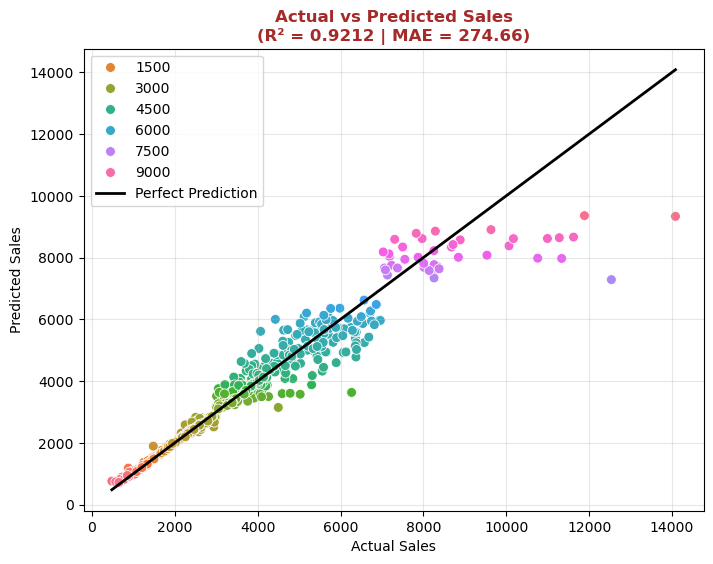

In [319]:
sns.set_palette("husl")
plt.figure(figsize = (8,6))
sns.scatterplot(x = y_test,y = pred,legend=True,hue=pred,palette = 'husl',s = 50)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'black',lw = 2,label = 'Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(f'Actual vs Predicted Sales\n(R² = {r2:.4f} | MAE = {mae:.2f})',fontsize = 12,color = 'brown',fontweight = 'bold')
plt.legend()
plt.grid(True,alpha = 0.3)
plt.show()

In [321]:
!git --version

git version 2.53.0.windows.2


In [326]:
!git config --global user.email "namitsenjaliya123@gmail.com"

In [327]:
!git config --global user.name "Namit865"

In [328]:
!git add .
!git commit -m "Add sales analysis project"

[master (root-commit) 5e4b017] Add sales analysis project
 3 files changed, 3340 insertions(+)
 create mode 100644 .ipynb_checkpoints/sales_analysis-checkpoint.ipynb
 create mode 100644 sales_analysis.ipynb
 create mode 100644 sales_data_sample.csv


In [329]:
!git branch -M master

In [330]:
!git push -u origin master

branch 'master' set up to track 'origin/master'.


remote: 
remote: Create a pull request for 'master' on GitHub by visiting:        
remote:      https://github.com/Namit865/data-analysis-portfolio/pull/new/master        
remote: 
To https://github.com/Namit865/data-analysis-portfolio.git
 * [new branch]      master -> master
